## 바이오 빅데이터 분석 (3B)
### 분류 분석 실습: TCGA-BRCA gene expression 기반 호르몬 수용체 상태 및 subtype 예측

이 노트북은 TCGA-BRCA 유방암 cohort의 gene expression 데이터와 clinical annotation을 사용해 분류 문제를 실습하는 자료입니다.

실습의 주요 흐름은 다음과 같습니다.

1. 데이터 로드
2. 데이터 탐색
3. 전처리
4. 이진 분류: ER hormone receptor status 예측
5. Cross-validation으로 일반화 성능 추정
6. ROC & AUC
7. GridSearchCV로 Logistic Regression 하이퍼파라미터 최적화
8. 모델 비교
9. 생존분석: 실제/예측 ER status와 overall survival
10. Feature importance: LASSO/ElasticNet 계수로 예측 유전자 확인
11. 다중 클래스 분류: breast cancer subtype 예측
12. 다중 분류 평가와 one-vs-rest ROC-AUC
13. 차원 축소 시각화
14. 과제

CancerSEEK 실습에서는 train/test split과 threshold 변화까지 자세히 다루었습니다. 이 노트북에서는 내용이 많아지므로, 성능 평가는 더 안정적인 cross-validation 중심으로 진행합니다.


### 0. 실행 환경

로컬 폴더의 `data_TCGA_BRCA/*.csv` 파일을 우선 사용합니다. 데이터 파일이 없는 환경에서는 기존 `MLBI_Training_pkg` 안의 TCGA-BRCA 폴더를 자동으로 찾아봅니다.

생존분석에는 `lifelines`가 필요합니다. 설치되어 있지 않은 환경에서는 아래 설치 셀의 주석을 해제한 뒤 실행하세요.


In [ ]:
# Colab 또는 새 환경에서 필요한 경우에만 실행하세요.
# !pip install lifelines
# !pip install xgboost
# !pip install umap-learn

In [ ]:
import os
from pathlib import Path
import warnings

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics as met
from sklearn import model_selection as mod_sel
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

warnings.filterwarnings('ignore')
RANDOM_STATE = 5
sns.set_theme(style='whitegrid', context='notebook')
np.set_printoptions(precision=3, suppress=True)
pd.options.display.float_format = '{:.3f}'.format


### 1. 데이터 로드

TCGA-BRCA 데이터는 두 개의 표로 구성됩니다.

- `TCGA_BRCA_gene_exp.csv`: 유전자 x 샘플 발현 행렬
- `TCGA_BRCA_clinical_data_used.csv`: 샘플별 receptor status, subtype, survival 정보

gene expression 파일은 행이 유전자, 열이 샘플이므로 이후 분석을 위해 샘플 x 유전자 형태로 transpose합니다.


In [ ]:
def load_tcga_brca(base_dir='data_TCGA_BRCA'):
    """Load TCGA-BRCA expression and clinical data from local or known workshop folders."""
    candidate_dirs = [
        Path(base_dir),
        Path('Work_BioBigdata_KOTHEA') / base_dir,
    ]

    for base in candidate_dirs:
        exp_file = base / 'TCGA_BRCA_gene_exp.csv'
        clinical_file = base / 'TCGA_BRCA_clinical_data_used.csv'
        if exp_file.exists() and clinical_file.exists():
            gene_exp = pd.read_csv(exp_file, index_col=0)
            clinical = pd.read_csv(clinical_file, index_col=0)
            print('Loaded data from:', base)
            return {'gene_expression': gene_exp, 'clinical_info': clinical}

    raise FileNotFoundError('TCGA-BRCA CSV files were not found. Check data_TCGA_BRCA/.')


data = load_tcga_brca()
df_gexp_raw = data['gene_expression']
df_clinical = data['clinical_info']

summary_cols = ['ER.Status', 'PR.Status', 'HER2.Final.Status', 'subtype', 'PAM50.class', 'OS.event', 'OS.Time']

print('raw gene expression:', df_gexp_raw.shape)
print('clinical info      :', df_clinical.shape)


#### Data source

Firebrowse by Broad Institute: http://firebrowse.org/

In [ ]:
display(df_gexp_raw.iloc[:5, :5])
display(df_clinical[['er.status', 'pr.status', 'her2.status', 'subtype', 'OS.Time', 'OS.event']].head())

### 2. 데이터 탐색

먼저 ER/PR/HER2 receptor status, subtype, survival event/time 분포를 확인합니다. 분류 문제에서는 class별 샘플 수가 성능 평가에 큰 영향을 주므로 class imbalance를 먼저 봐야 합니다.


In [ ]:
summary_cols = ['er.status', 'pr.status', 'her2.status', 'subtype', 'OS.event']
for col in summary_cols:
    if col in df_clinical.columns:
        print('\n###', col)
        display(df_clinical[col].value_counts(dropna=False).to_frame('n_samples'))


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=df_clinical, x='er.status', order=['positive', 'negative'], color='steelblue', ax=axes[0])
axes[0].set_title('ER status')
axes[0].set_xlabel('')

sns.countplot(data=df_clinical, x='subtype', order=df_clinical['subtype'].value_counts().index, color='mediumseagreen', ax=axes[1])
axes[1].set_title('Breast cancer subtype')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

surv_df = df_clinical[['OS.Time', 'OS.event']].dropna().copy()
sns.histplot(data=surv_df, x='OS.Time', hue='OS.event', bins=40, element='step', ax=axes[2])
axes[2].set_title('Overall survival time')
axes[2].set_xlabel('Days')

plt.tight_layout()


### 3. 전처리

유전자 이름은 `GENE|ID` 형태로 들어있는 경우가 많습니다. 여기서는 `|` 앞의 gene symbol을 사용하고, symbol이 비어 있거나 `?`인 유전자는 제거합니다. 중복 gene symbol은 평균값으로 합칩니다.

실습 속도를 위해 분산이 큰 유전자 1,000개를 사용합니다. 전체 유전자를 사용하려면 `TOP_N_GENES = None`으로 바꾸세요.


In [ ]:
def clean_gene_expression(raw_gene_exp):
    gene_symbols = raw_gene_exp.index.to_series().astype(str).str.split('|').str[0]
    valid = gene_symbols.notna() & (gene_symbols != '') & (gene_symbols != '?')

    gene_exp = raw_gene_exp.loc[valid].copy()
    gene_exp.index = gene_symbols.loc[valid]
    gene_exp = gene_exp.groupby(gene_exp.index).mean()

    # genes x samples -> samples x genes
    return gene_exp.T


df_gexp = clean_gene_expression(df_gexp_raw)
common_samples = df_gexp.index.intersection(df_clinical.index)
df_gexp = df_gexp.loc[common_samples].copy()
clinical = df_clinical.loc[common_samples].copy()

print('sample x gene expression:', df_gexp.shape)
print('matched clinical        :', clinical.shape)
print('missing expression values:', int(df_gexp.isna().sum().sum()))


In [ ]:
# TCGA expression matrix in this file is already continuous expression values.
# log-transform is not applied again because the values are already on a log-like scale.
df_feature_all = df_gexp.copy()

TOP_N_GENES = 3000
if TOP_N_GENES is None or TOP_N_GENES >= df_feature_all.shape[1]:
    selected_genes = df_feature_all.columns
else:
    selected_genes = df_feature_all.var(axis=0).sort_values(ascending=False).head(TOP_N_GENES).index

df_feature = df_feature_all.loc[:, selected_genes].copy()
print('Selected feature matrix:', df_feature.shape)
display(df_feature.iloc[:5, :8])


### 4. 이진 분류: ER hormone receptor status 예측

첫 번째 문제는 gene expression으로 ER status를 예측하는 binary classification입니다. ER status는 유방암 치료 전략과 subtype biology를 이해하는 데 중요한 receptor marker입니다.

- `Positive`: ER positive
- `Negative`: ER negative

모델은 `LogisticRegression`을 기본으로 사용하고, cross-validation으로 일반화 성능을 평가합니다.


## Model:

### (Binary) Logistic regression with $l_1$ and $l_2$ penalty
model description: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression  
model usage: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

#### Model (logistic sigmoid function): $$ \hat{p}_1 = \frac{1}{1 + e^{-({\bf{x}}_i^T {\boldsymbol{\theta}} + c)}} $$

`decision_function`은 sigmoid 함수에 들어가기 전의 선형 score입니다. score가 클수록 Positive class로 예측될 가능성이 높습니다.


In [ ]:
def binary_classification_scores(y_true, y_pred, y_score=None):
    labels = [0, 1]
    tn, fp, fn, tp = met.confusion_matrix(y_true, y_pred, labels=labels).ravel()
    scores = {
        'accuracy': met.accuracy_score(y_true, y_pred),
        'balanced_accuracy': met.balanced_accuracy_score(y_true, y_pred),
        'sensitivity_recall': tp / (tp + fn) if (tp + fn) else np.nan,
        'specificity': tn / (tn + fp) if (tn + fp) else np.nan,
        'precision_ppv': met.precision_score(y_true, y_pred, zero_division=0),
        'f1': met.f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        scores['roc_auc'] = met.roc_auc_score(y_true, y_score)
        scores['average_precision'] = met.average_precision_score(y_true, y_score)
    return scores


def plot_binary_confusion_matrix(y_true, y_pred, title='Confusion matrix'):
    cm = met.confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = met.ConfusionMatrixDisplay(cm, display_labels=['ER Negative', 'ER Positive'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.grid(False)
    plt.tight_layout()


In [ ]:
er_mask = clinical['er.status'].isin(['positive', 'negative'])
X_er = df_feature.loc[er_mask].copy()
y_er_label = clinical.loc[er_mask, 'er.status'].copy()
y_er = y_er_label.map({'negative': 0, 'positive': 1}).astype(int)
info_er = clinical.loc[er_mask].copy()

print('ER prediction samples:', X_er.shape[0])
print('Features             :', X_er.shape[1])
display(y_er_label.value_counts().to_frame('n_samples'))


### 5. Cross-validation으로 일반화 성능 추정

CancerSEEK 실습에서 train/test split을 이미 다루었으므로, 여기서는 `StratifiedKFold` cross-validation으로 더 안정적인 성능을 추정합니다.


#### 교차검증 절차 모식도

<div style="display:flex; gap:24px; align-items:flex-start;">
  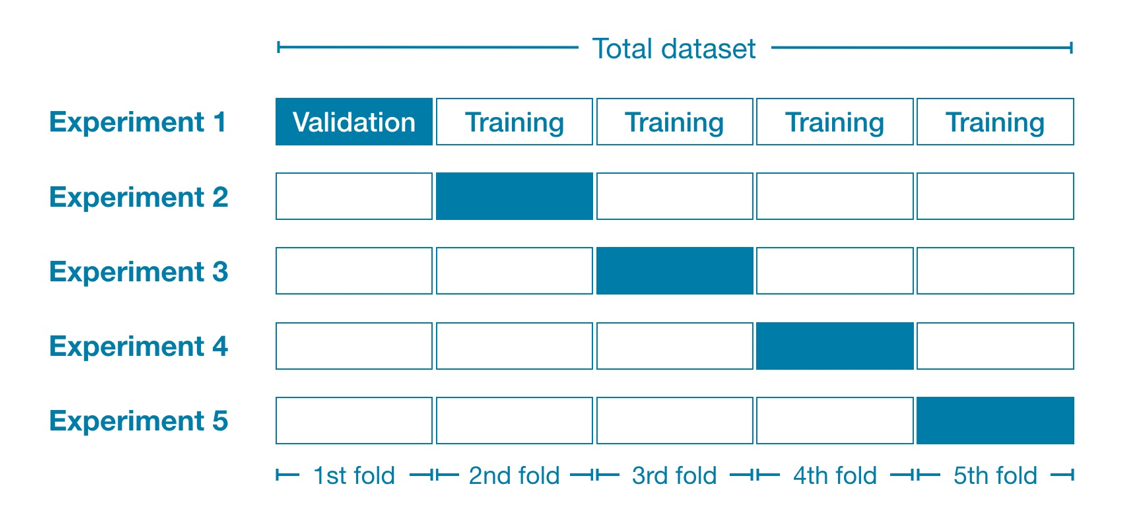  
</div>


In [ ]:
NCV = 5
cv = mod_sel.StratifiedKFold(n_splits=NCV, shuffle=True, random_state=RANDOM_STATE)

binary_cv_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='elasticnet',
        l1_ratio=1,
        C=1,
        solver='saga',
        class_weight='balanced',
        max_iter=400,
        random_state=RANDOM_STATE,
        n_jobs=10,
    )),
])

y_pred_cv = mod_sel.cross_val_predict(binary_cv_model, X_er, y_er, cv=cv, n_jobs=-1, method='predict')
y_score_cv = mod_sel.cross_val_predict(binary_cv_model, X_er, y_er, cv=cv, n_jobs=-1, method='decision_function')
y_prob_cv = mod_sel.cross_val_predict(binary_cv_model, X_er, y_er, cv=cv, n_jobs=-1, method='predict_proba')[:, 1]

pd.Series(binary_classification_scores(y_er, y_pred_cv, y_score_cv), name=f'ER status {NCV}-fold CV')


In [ ]:
plot_binary_confusion_matrix(y_er, y_pred_cv, title=f'ER status prediction: {NCV}-fold CV')


#### 예측 score 분포 확인

`y_score_cv`는 cross-validation에서 계산한 decision score입니다. score가 0보다 크면 ER positive class 쪽으로 예측됩니다. ER Negative와 ER Positive의 score 분포가 잘 분리될수록 ROC-AUC가 높습니다.

일부 샘플은 매우 큰 절대값의 decision score를 가질 수 있습니다. 이런 outlier가 x축을 지나치게 넓히면 중심부 분포가 잘 보이지 않으므로, 아래 그림에서는 시각화용으로만 score를 `[-50, 50]` 범위로 clipping합니다. ROC-AUC 계산에는 원래 score를 그대로 사용합니다.


In [ ]:
SCORE_CLIP_RANGE = (-30, 20)

score_df = pd.DataFrame({
    'Decision score': y_score_cv,
    'True ER status': y_er_label.values,
})
score_df['Decision score (clipped)'] = score_df['Decision score'].clip(*SCORE_CLIP_RANGE)

print('Original score range :', (float(score_df['Decision score'].min()), float(score_df['Decision score'].max())))
print('Clipped display range:', SCORE_CLIP_RANGE)

plt.figure(figsize=(7, 4.5))
sns.histplot(
    data=score_df,
    x='Decision score (clipped)',
    hue='True ER status',
    bins=50,
    stat='density',
    common_norm=False,
    alpha=0.35,
    element='step',
)
sns.kdeplot(
    data=score_df,
    x='Decision score (clipped)',
    hue='True ER status',
    common_norm=False,
    linewidth=2,
    legend=False,
)
plt.axvline(0, color='black', linestyle='--', linewidth=1, label='decision threshold = 0')
plt.xlabel('Decision score before logistic sigmoid (clipped for display)')
plt.ylabel('Density')
plt.title('Cross-validated ER status decision score distribution')
# plt.legend(loc='upper center')
plt.tight_layout()


### 6. ROC & AUC

ROC curve는 threshold 변화에 따라 false positive rate와 true positive rate가 어떻게 변하는지 보여줍니다. AUC는 모델이 ER positive sample에 ER negative sample보다 더 높은 score를 줄 확률로 해석할 수 있습니다.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

met.RocCurveDisplay.from_predictions(y_er, y_score_cv, ax=axes[0], name='Logistic regression')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title('ROC curve')

met.PrecisionRecallDisplay.from_predictions(y_er, y_score_cv, ax=axes[1], name='Logistic regression')
axes[1].set_title('Precision-Recall curve')

plt.tight_layout()


### 7. GridSearchCV로 Logistic Regression 하이퍼파라미터 최적화

`elasticnet` penalty를 고정한 뒤 ROC-AUC를 기준으로 `C`와 `l1_ratio`를 함께 탐색합니다. `l1_ratio=1`에 가까울수록 LASSO처럼 feature selection 효과가 커집니다.


실습 시간을 줄이기 위해 GridSearchCV는 3-fold와 작은 parameter grid를 사용합니다. 더 정밀한 탐색이 필요하면 `param_grid` 후보를 늘리면 됩니다.


In [ ]:
grid_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        class_weight='balanced',
        max_iter=400,
    )),
])

param_grid = {
    'model__C': [0.25, 0.5, 1, 2],
    'model__l1_ratio': [0, 0.5, 1.0],
}

NCV = 5
cv = mod_sel.StratifiedKFold(n_splits=NCV, shuffle=True)

gs = mod_sel.GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv, 
    n_jobs=-1,
    verbose=1,
)

gs.fit(X_er, y_er)
print('Best CV score:', round(gs.best_score_, 3))
print('Best params:', gs.best_params_)


In [ ]:
best_binary_model = gs.best_estimator_
y_pred_best_cv = mod_sel.cross_val_predict(best_binary_model, X_er, y_er, cv=cv, n_jobs=-1, method='predict')
# y_score_best_cv = mod_sel.cross_val_predict(best_binary_model, X_er, y_er, cv=cv, n_jobs=-1, method='decision_function')
# y_prob_best_cv = mod_sel.cross_val_predict(best_binary_model, X_er, y_er, cv=cv, n_jobs=-1, method='predict_proba')[:, 1]

pd.Series(binary_classification_scores(y_er, y_pred_best_cv, y_score_best_cv), name='Best logistic regression CV')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
met.RocCurveDisplay.from_predictions(y_er, y_score_best_cv, ax=axes[0], name='Best logistic reg.')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title('ROC curve')

met.PrecisionRecallDisplay.from_predictions(y_er, y_score_best_cv, ax=axes[1], name='Best logistic reg.')
axes[1].set_title('Precision-Recall curve')
plt.tight_layout()


### 8. RandomForest 및 XGBoost 모델과 성능 비교

같은 ER status prediction 문제에 대해 Logistic Regression, RandomForest, XGBoost를 비교합니다. tree 기반 모델은 `decision_function`이 없으므로 ROC용 score로 predicted probability를 사용합니다.


In [ ]:
binary_models = {
    'LogisticRegression': best_binary_model,
    'RandomForest': RandomForestClassifier(
        n_estimators=150,
        max_features='sqrt',
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

try:
    from xgboost import XGBClassifier
    n_negative = int((y_er == 0).sum())
    n_positive = int((y_er == 1).sum())
    binary_models['XGBoost'] = XGBClassifier(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=n_negative / n_positive,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
except ImportError:
    print('xgboost is not installed. XGBoost will be skipped.')

model_rows = []
model_scores = {}
for model_name, model in binary_models.items():
    print('Evaluating:', model_name)
    y_pred = mod_sel.cross_val_predict(model, X_er, y_er, cv=cv, n_jobs=-1, method='predict')
    if hasattr(model, 'decision_function'):
        y_model_score = mod_sel.cross_val_predict(model, X_er, y_er, cv=cv, n_jobs=-1, method='decision_function')
    else:
        y_model_score = mod_sel.cross_val_predict(model, X_er, y_er, cv=cv, n_jobs=-1, method='predict_proba')[:, 1]
    model_scores[model_name] = y_model_score
    row = binary_classification_scores(y_er, y_pred, y_model_score)
    row['model'] = model_name
    model_rows.append(row)

binary_model_result_df = pd.DataFrame(model_rows).set_index('model').sort_values('roc_auc', ascending=False)
binary_model_result_df


In [ ]:
plt.figure(figsize=(6, 5))
ax = plt.gca()
for model_name, y_model_score in model_scores.items():
    met.RocCurveDisplay.from_predictions(y_er, y_model_score, name=model_name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_title('ROC curve: model comparison')
plt.tight_layout()


### 9. 생존분석: 실제/예측 ER status와 overall survival

분류 모델이 구분한 ER status가 임상 outcome과 어떤 관계를 갖는지 살펴봅니다. Kaplan-Meier survival curve를 사용해 실제 ER status와 예측 ER status별 overall survival을 비교합니다.

아래 그림에서 곡선 주변의 색칠된 영역은 표준편차가 아니라 Kaplan-Meier 생존확률의 95% confidence interval입니다. 표본 수가 적거나 censoring이 많으면 confidence interval이 넓어질 수 있습니다.

주의: 이 분석은 실습용 예시입니다. 치료, stage, age 등 confounder를 보정하지 않았기 때문에 인과적 결론으로 해석하면 안 됩니다.


In [ ]:
try:
    import lifelines
    from lifelines.statistics import logrank_test
    LIFELINES_AVAILABLE = True
except ImportError:
    LIFELINES_AVAILABLE = False
    print('lifelines is not installed. Install lifelines to run survival analysis.')


def plot_km_by_group(times, events, groups, title=None, ax=None, show_ci=True, ci_alpha=0.18):
    """Draw Kaplan-Meier curves by group with optional 95% confidence bands."""
    # lifelines가 설치되어 있지 않으면 분석을 건너뜁니다.
    if not LIFELINES_AVAILABLE:
        print('lifelines is not installed.')
        return None

    # 외부에서 axis를 주지 않으면 현재 matplotlib axis를 사용합니다.
    if ax is None:
        ax = plt.gca()

    # survival 분석에 필요한 time, event, group 열만 모아 결측값을 제거합니다.
    df_surv = pd.DataFrame({'time': times, 'event': events, 'group': groups}).dropna()

    # follow-up 시간이 0보다 큰 샘플만 남깁니다.
    df_surv = df_surv[df_surv['time'] > 0].copy()

    # Kaplan-Meier estimator를 준비합니다.
    kmf = lifelines.KaplanMeierFitter()

    # group별로 Kaplan-Meier curve를 학습하고 그립니다.
    for group_name, sub_df in df_surv.groupby('group'):
        # 각 group의 생존시간과 event 정보를 사용해 KM curve를 적합합니다.
        kmf.fit(sub_df['time'], event_observed=sub_df['event'], label=f'{group_name} (n={len(sub_df)})')

        # ci_show=True이면 곡선 주변에 95% confidence interval band가 색칠됩니다.
        kmf.plot_survival_function(ax=ax, ci_show=show_ci, ci_alpha=ci_alpha, linewidth=2)

    # group이 2개일 때만 log-rank test를 계산합니다.
    unique_groups = list(df_surv['group'].dropna().unique())
    if len(unique_groups) == 2:
        g0, g1 = unique_groups
        d0 = df_surv[df_surv['group'] == g0]
        d1 = df_surv[df_surv['group'] == g1]

        # 두 group의 survival curve 차이를 log-rank test로 평가합니다.
        res = logrank_test(d0['time'], d1['time'], event_observed_A=d0['event'], event_observed_B=d1['event'])
        ax.text(0.04, 0.08, f'log-rank p = {res.p_value:.2e}', transform=ax.transAxes)

    # 축, 제목, 격자를 정리합니다.
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Overall survival')
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.35)
    return ax


In [ ]:
surv_er = info_er.copy()
surv_er['ER status true'] = y_er_label.values
surv_er['ER status predicted'] = np.where(y_pred_best_cv == 1, 'positive', 'negative')
surv_er['Hormone Therapy'] = np.where( surv_er['hormone.therapy'] > 0, 'HT treated', 'HT not treated' )
surv_er['OS.Time.years'] = surv_er['OS.Time'] / 365.25

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

b = surv_er['ER status true'] == 'positive'
plot_km_by_group(
    surv_er.loc[b, 'OS.Time.years'],
    surv_er.loc[b, 'OS.event'],
    surv_er.loc[b, 'Hormone Therapy'],
    title='Survival by true ER status',
    ax=axes[0],
)

b = surv_er['ER status predicted'] == 'positive'
plot_km_by_group(
    surv_er.loc[b, 'OS.Time.years'],
    surv_er.loc[b, 'OS.event'],
    surv_er.loc[b, 'Hormone Therapy'],
    title='Survival by predicted ER status',
    ax=axes[1],
)
plt.tight_layout()


In [ ]:
surv_er = info_er.copy()
surv_er['ER status true'] = y_er_label.values
surv_er['ER status predicted'] = np.where(y_pred_best_cv == 1, 'positive', 'negative')
surv_er['Hormone Therapy'] = np.where( surv_er['hormone.therapy'] > 0, 'HT treated', 'HT not treated' )
surv_er['OS.Time.years'] = surv_er['OS.Time'] / 365.25

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

b = surv_er['hormone.therapy'] > 0
plot_km_by_group(
    surv_er.loc[b, 'OS.Time.years'],
    surv_er.loc[b, 'OS.event'],
    surv_er.loc[b, 'ER status true'],
    title='Survival by true ER status',
    ax=axes[0],
)

b = surv_er['hormone.therapy'] > 0
plot_km_by_group(
    surv_er.loc[b, 'OS.Time.years'],
    surv_er.loc[b, 'OS.event'],
    surv_er.loc[b, 'ER status predicted'],
    title='Survival by predicted ER status',
    ax=axes[1],
)
plt.tight_layout()


### 10. Feature importance: LASSO/ElasticNet 계수로 예측 유전자 확인

ElasticNet/LASSO logistic regression은 일부 유전자의 계수를 0에 가깝게 만들 수 있어 feature selection 효과가 있습니다. 여기서는 GridSearchCV에서 선택된 best logistic regression model을 전체 ER status 데이터에 다시 학습하고, 절대값이 큰 계수를 가진 유전자를 확인합니다.


In [ ]:
importance_model = best_binary_model
importance_model.fit(X_er, y_er)

feature_names = np.array(X_er.columns)
coef = importance_model.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'gene': feature_names,
    'coef': coef,
    'abs_coef': np.abs(coef),
}).sort_values('abs_coef', ascending=False)

nonzero_coef_df = coef_df[coef_df['coef'] != 0].copy()
print('Number of non-zero coefficient genes:', len(nonzero_coef_df))
display(coef_df.head(25))


In [ ]:
top_n = 25
top_coef_df = coef_df.head(top_n).copy().sort_values('coef')

plt.figure(figsize=(8, 7))
sns.barplot(
    data=top_coef_df,
    x='coef',
    y='gene',
    hue=top_coef_df['coef'] > 0,
    dodge=False,
    palette={True: 'firebrick', False: 'steelblue'},
)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('ElasticNet logistic regression coefficient')
plt.ylabel('Gene')
plt.title(f'Top {top_n} genes for ER status prediction')
plt.legend(title='Higher expression predicts', labels=['ER Negative', 'ER Positive'])
plt.tight_layout()


#### 선택 실습: 선택된 유전자만 사용한 성능

계수 절대값 상위 유전자만 사용해도 ER status 예측이 어느 정도 가능한지 확인합니다.


In [ ]:
TOP_N_SELECTED = 50
selected_importance_genes = coef_df.head(TOP_N_SELECTED)['gene'].tolist()
X_er_selected = X_er[selected_importance_genes].copy()

selected_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1.0, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)),
])

y_pred_selected_cv = mod_sel.cross_val_predict(selected_model, X_er_selected, y_er, cv=cv, n_jobs=-1, method='predict')
y_score_selected_cv = mod_sel.cross_val_predict(selected_model, X_er_selected, y_er, cv=cv, n_jobs=-1, method='decision_function')

pd.Series(binary_classification_scores(y_er, y_pred_selected_cv, y_score_selected_cv), name=f'Top {TOP_N_SELECTED} genes CV')


### 11. 다중 클래스 분류: breast cancer subtype 예측

두 번째 문제는 gene expression으로 breast cancer subtype을 예측하는 multiclass classification입니다. 여기서는 clinical table의 `subtype` 컬럼을 사용합니다.

- Lum.A
- Lum.B
- Basal
- Her2


## Model:

### (Multinomial) Logistic regression with $l_1$ and $l_2$ penalty

Multiclass logistic regression은 softmax 함수를 사용해 각 class에 속할 score/probability를 계산합니다.


In [ ]:
subtype_mask = clinical['subtype'].notna()
X_subtype = df_feature.loc[subtype_mask].copy()
y_subtype = clinical.loc[subtype_mask, 'subtype'].copy()

print('Subtype prediction samples:', X_subtype.shape[0])
print('Features                  :', X_subtype.shape[1])
display(y_subtype.value_counts().to_frame('n_samples'))


In [ ]:
subtype_cv_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1.0, class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE)),
])

cv_multi = mod_sel.StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_pred_subtype_cv = mod_sel.cross_val_predict(subtype_cv_model, X_subtype, y_subtype, cv=cv_multi, n_jobs=-1, method='predict')

print(met.classification_report(y_subtype, y_pred_subtype_cv, digits=3))
print('Balanced accuracy:', round(met.balanced_accuracy_score(y_subtype, y_pred_subtype_cv), 3))
print('Macro F1:', round(met.f1_score(y_subtype, y_pred_subtype_cv, average='macro'), 3))


In [ ]:
subtype_cv_model.fit(X_subtype, y_subtype)
classes_subtype = subtype_cv_model.named_steps['model'].classes_
cm = met.confusion_matrix(y_subtype, y_pred_subtype_cv, labels=classes_subtype)
cm_norm = met.confusion_matrix(y_subtype, y_pred_subtype_cv, labels=classes_subtype, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes_subtype, yticklabels=classes_subtype, ax=axes[0])
axes[0].set_title('Subtype confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=classes_subtype, yticklabels=classes_subtype, ax=axes[1])
axes[1].set_title('Normalized by true class')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()


### 12. 다중 분류 평가와 one-vs-rest ROC-AUC

다중 분류 ROC-AUC는 각 subtype을 양성 class로 두고 나머지 subtype을 음성 class로 두는 one-vs-rest 방식으로 계산합니다. 여기서는 multiclass logistic regression의 `decision_function` score를 사용합니다.


In [ ]:
y_score_subtype_cv = mod_sel.cross_val_predict(subtype_cv_model, X_subtype, y_subtype, cv=cv_multi, n_jobs=-1, method='decision_function')
y_subtype_bin = label_binarize(y_subtype, classes=classes_subtype)

subtype_roc_auc_macro = met.roc_auc_score(y_subtype_bin, y_score_subtype_cv, average='macro', multi_class='ovr')
subtype_roc_auc_weighted = met.roc_auc_score(y_subtype_bin, y_score_subtype_cv, average='weighted', multi_class='ovr')

pd.Series({
    'macro_ovr_roc_auc': subtype_roc_auc_macro,
    'weighted_ovr_roc_auc': subtype_roc_auc_weighted,
}, name='Subtype one-vs-rest ROC-AUC')


In [ ]:
auc_rows = []
for i, class_name in enumerate(classes_subtype):
    auc_rows.append({
        'subtype': class_name,
        'n_samples': int((y_subtype == class_name).sum()),
        'one_vs_rest_auc': met.roc_auc_score(y_subtype_bin[:, i], y_score_subtype_cv[:, i]),
    })

auc_by_subtype_df = pd.DataFrame(auc_rows).sort_values('one_vs_rest_auc', ascending=False)
auc_by_subtype_df


In [ ]:
plt.figure(figsize=(7, 5))
for i, class_name in enumerate(classes_subtype):
    fpr, tpr, _ = met.roc_curve(y_subtype_bin[:, i], y_score_subtype_cv[:, i])
    roc_auc = met.auc(fpr, tpr)
    n_samples = int((y_subtype == class_name).sum())
    plt.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC={roc_auc:.3f}, n={n_samples})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate / Sensitivity')
plt.title('One-vs-rest ROC curves by subtype')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.35)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()


### 13. 차원 축소 시각화

UMAP을 사용해 gene expression pattern을 2차원으로 살펴봅니다. 같은 좌표를 ER status와 subtype으로 각각 색칠하면, 두 label이 expression space에서 어떻게 구분되는지 직관적으로 볼 수 있습니다.

UMAP이 설치되어 있지 않거나 현재 환경에서 import되지 않으면 t-SNE로 자동 대체합니다. t-SNE는 비선형 구조를 보기 좋게 펼쳐주지만, 축 자체의 해석보다는 점들 사이의 상대적인 군집 경향을 중심으로 해석합니다.


In [ ]:
# UMAP/t-SNE는 subtype 분석에 사용한 샘플을 기준으로 계산합니다.
X_scaled_for_dr = StandardScaler().fit_transform(X_subtype)

try:
    import umap.umap_ as umap

    reducer = umap.UMAP(
        n_neighbors=20,
        min_dist=0.15,
        metric='euclidean',
        random_state=RANDOM_STATE,
    )
    X_2d = reducer.fit_transform(X_scaled_for_dr)
    dr_name = 'UMAP'
    dim_cols = ['UMAP1', 'UMAP2']
except Exception as exc:
    print('UMAP is not available in this environment. Falling back to t-SNE.')
    print(type(exc).__name__, exc)
    reducer = TSNE(
        n_components=2,
        learning_rate='auto',
        init='pca',
        random_state=RANDOM_STATE,
    )
    X_2d = reducer.fit_transform(X_scaled_for_dr)
    dr_name = 't-SNE'
    dim_cols = ['tSNE1', 'tSNE2']


dr_df = pd.DataFrame(X_2d, columns=dim_cols, index=X_subtype.index)
dr_df['subtype'] = y_subtype.values
dr_df['ER.Status'] = clinical.loc[X_subtype.index, 'ER.Status'].fillna('Unknown').values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=dr_df, x=dim_cols[0], y=dim_cols[1], hue='ER.Status', s=45, alpha=0.85, ax=axes[0])
axes[0].set_title(f'{dr_name} colored by ER status')
axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))

sns.scatterplot(data=dr_df, x=dim_cols[0], y=dim_cols[1], hue='subtype', s=45, alpha=0.85, ax=axes[1], palette='tab10')
axes[1].set_title(f'{dr_name} colored by subtype')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()


### 14. 과제

다음 항목을 포함해 짧은 분석 보고서를 작성하세요.

1. ER status prediction에서 Logistic Regression, RandomForest, XGBoost의 성능을 비교하시오.
2. GridSearchCV에서 선택된 `C`와 `l1_ratio`를 확인하고, 이 값이 모델 복잡도와 feature selection에 어떤 의미를 갖는지 설명하시오.
3. 실제 ER status와 예측 ER status에 따른 Kaplan-Meier curve를 비교하고, 두 그림의 차이를 해석하시오.
4. ER status prediction에서 중요한 유전자 상위 10개를 고르고, 알려진 유방암 biology와 관련이 있는지 조사하시오.
5. subtype multiclass classification에서 가장 잘 예측되는 subtype과 가장 어려운 subtype을 confusion matrix와 class별 AUC 관점에서 설명하시오.


### 정리 질문

- ER status와 subtype은 gene expression pattern에서 어떻게 연결되어 있을까요?
- ROC-AUC가 높아도 clinical decision에 바로 사용할 수 없는 이유는 무엇일까요?
- Kaplan-Meier curve와 log-rank test는 어떤 질문에 답해주고, 어떤 한계를 가질까요?
- LASSO/ElasticNet 계수가 큰 유전자를 biological marker로 해석할 때 주의할 점은 무엇일까요?
- subtype 다중 분류에서 macro F1과 weighted F1이 다르게 나오는 이유는 무엇일까요?
